# TDT PLN — Prueba de Concepto
**MULCIA · Procesamiento del Lenguaje Natural 2025–26**



## 0. Entorno y dependencias

In [52]:
# Instalar dependencias si no están disponibles
# Descomentar según necesidad

# !pip install scikit-learn pandas numpy matplotlib seaborn datasets
# !pip install nltk spacy
# !python -m spacy download es_core_news_sm   # modelo español
# !python -m nltk.downloader stopwords punkt

In [53]:
# ── Imports estándar ──────────────────────────────────────
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn ──────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.utils import resample

# ── Reproducibilidad ──────────────────────────────────────
SEED = 42
np.random.seed(SEED)

print('Entorno listo.')

Entorno listo.


## 1. Carga de datos

Fuente del dataset: https://huggingface.co/datasets/AmazonScience/massive?utm_source=chatgpt.com 

> Se carga `AmazonScience/massive` filtrado a `scenario == "cooking"` y `locale in {"en-US", "es-ES"}`.  
> Para clasificación se usa `faq_label`, que conserva solo los marcadores `<slot>` de `annot_utt` y evita usar `intent_name`.

In [54]:
# ── MASSIVE: cooking bilingüe, sin dividir aún en train/test ──────────
try:
    from datasets import load_dataset
except ImportError as exc:
    raise ImportError(
        "Falta la librería `datasets`. Instálala con `pip install datasets`."
    ) from exc

import re

DATASET_NAME = "AmazonScience/massive"
LOCALES = ["en-US", "es-ES"]
TARGET_SCENARIO = "cooking"
NO_ANNOT_LABEL = "no_annot"
PARQUET_SPLITS = ["train", "validation", "test"]

# `datasets` recientes ya no ejecutan scripts remotos como `massive.py`.
# Por eso cargamos directamente los Parquet exportados en el Hub.
SCENARIO_LABELS = [
    "social", "transport", "calendar", "play", "news", "datetime",
    "recommendation", "email", "iot", "general", "audio", "lists",
    "qa", "cooking", "takeaway", "music", "alarm", "weather"
]
INTENT_LABELS = [
    "datetime_query", "iot_hue_lightchange", "transport_ticket", "takeaway_query",
    "qa_stock", "general_greet", "recommendation_events", "music_dislikeness",
    "iot_wemo_off", "cooking_recipe", "qa_currency", "transport_traffic",
    "general_quirky", "weather_query", "audio_volume_up", "email_addcontact",
    "takeaway_order", "email_querycontact", "iot_hue_lightup", "recommendation_locations",
    "play_audiobook", "lists_createoradd", "news_query", "alarm_query",
    "iot_wemo_on", "general_joke", "qa_definition", "social_query",
    "music_settings", "audio_volume_other", "calendar_remove", "iot_hue_lightdim",
    "calendar_query", "email_sendemail", "iot_cleaning", "audio_volume_down",
    "play_radio", "cooking_query", "datetime_convert", "qa_maths",
    "iot_hue_lightoff", "iot_hue_lighton", "transport_query", "music_likeness",
    "email_query", "play_music", "audio_volume_mute", "social_post",
    "alarm_set", "qa_factoid", "calendar_set", "play_game", "alarm_remove",
    "lists_remove", "transport_taxi", "recommendation_movies", "iot_coffee",
    "music_query", "play_podcasts", "lists_query"
]

def massive_parquet_url(locale: str, split: str) -> str:
    return (
        f"https://huggingface.co/datasets/{DATASET_NAME}/resolve/"
        f"refs%2Fconvert%2Fparquet/{locale}/{split}/0000.parquet"
    )

def normalizar_label(valor, labels):
    if isinstance(valor, (int, np.integer)):
        return labels[int(valor)]
    if isinstance(valor, (float, np.floating)) and float(valor).is_integer():
        return labels[int(valor)]
    if isinstance(valor, str) and valor.isdigit():
        return labels[int(valor)]
    return str(valor)

def extraer_slots_de_annot(annot_utt: str) -> list[str]:
    if pd.isna(annot_utt):
        return []
    return [slot.strip() for slot in re.findall(r'\[([^\[:]+?)\s*:', str(annot_utt))]

def extraer_slots(row: pd.Series) -> list[str]:
    slot_method = row.get("slot_method")
    if isinstance(slot_method, dict):
        slots = slot_method.get("slot", [])
        if isinstance(slots, list) and len(slots) > 0:
            return [str(slot) for slot in slots]
    return extraer_slots_de_annot(row.get("annot_utt", ""))

def firmar_slots(slots: list[str]) -> str:
    slots = sorted({str(slot) for slot in slots if str(slot).strip()})
    return '+'.join(slots) if slots else 'no_slot'

def simplificar_annot(annot_utt: str) -> str:
    if pd.isna(annot_utt):
        return NO_ANNOT_LABEL
    slots = [slot.strip() for slot in re.findall(r'\[([^\[:]+?)\s*:', str(annot_utt))]
    tags = [f"<{slot}>" for slot in slots if slot]
    return ' '.join(tags) if tags else NO_ANNOT_LABEL

def preparar_dataset(ds) -> pd.DataFrame:
    df = ds.to_pandas()
    df["scenario_name"] = df["scenario"].apply(lambda x: normalizar_label(x, SCENARIO_LABELS))
    df["intent_name"] = df["intent"].apply(lambda x: normalizar_label(x, INTENT_LABELS))
    df = df[df["scenario_name"] == TARGET_SCENARIO].copy()
    df["text"] = df["utt"].astype(str)
    df["idioma"] = df["locale"].astype(str)
    df["slots"] = df.apply(extraer_slots, axis=1)
    df["slot_signature"] = df["slots"].apply(firmar_slots)
    df["annot_slots_only"] = df["annot_utt"].apply(simplificar_annot)
    df["n_slots"] = df["slots"].apply(len)
    df["n_tokens"] = df["text"].str.split().str.len()
    df["n_chars"] = df["text"].str.len()
    columnas = [
        "id", "locale", "idioma", "partition", "scenario", "scenario_name",
        "intent", "intent_name", "utt", "text", "annot_utt", "annot_slots_only",
        "worker_id", "slot_method", "judgments", "slots", "slot_signature",
        "n_slots", "n_tokens", "n_chars"
    ]
    return df[columnas].reset_index(drop=True)

parquet_urls = [
    massive_parquet_url(locale, split)
    for locale in LOCALES
    for split in PARQUET_SPLITS
]
raw_full = load_dataset("parquet", data_files={"full": parquet_urls})["full"]
ATRIBUTOS_ORIGINALES = raw_full.column_names

df_cooking = preparar_dataset(raw_full)

# Etiqueta FAQ simplificada: solo marcadores <slot> de annot_utt.
# Si una utterance no trae anotación inline, usamos la firma de slots.
df_cooking['faq_label'] = df_cooking['annot_slots_only']
mask_no_annot = df_cooking['faq_label'].eq(NO_ANNOT_LABEL)
df_cooking.loc[mask_no_annot, 'faq_label'] = 'slots=' + df_cooking.loc[mask_no_annot, 'slot_signature']
faq_freq = df_cooking['faq_label'].value_counts().sort_values(ascending=False)
df_cooking['faq_label_freq'] = df_cooking['faq_label'].map(faq_freq)

df_slots = df_cooking.explode("slots").rename(columns={"slots": "slot"}).copy()
df_slots = df_slots[df_slots["slot"].notna() & (df_slots["slot"].astype(str).str.len() > 0)].copy()
df_slots["slot"] = df_slots["slot"].astype(str)

intent_freq = df_cooking["intent_name"].value_counts().sort_values(ascending=False)
slot_freq = df_slots["slot"].value_counts().sort_values(ascending=False)
faq_freq = df_cooking['faq_label'].value_counts().sort_values(ascending=False)
atributos_info = pd.DataFrame([
    {
        "atributo": col,
        "dtype": str(df_cooking[col].dtype) if col in df_cooking.columns else "no disponible",
        "ejemplo": str(df_cooking[col].dropna().iloc[0])[:100] if col in df_cooking.columns and df_cooking[col].notna().any() else ""
    }
    for col in ATRIBUTOS_ORIGINALES
])
atributos_derivados = pd.DataFrame([
    {'atributo_derivado': 'annot_slots_only', 'descripcion': 'solo los marcadores <slot> extraídos de annot_utt'},
    {'atributo_derivado': 'slot_signature', 'descripcion': 'firma compacta de slots presentes en la pregunta'},
    {'atributo_derivado': 'faq_label', 'descripcion': 'etiqueta de clasificación basada en <slot> y fallback a slots'},
])

print("Carga realizada desde Parquet exportado del Hub.")
print("Si aparece un aviso sobre HF_TOKEN, es solo un warning de cuota/rate limit.")
print()
print(f"Dataset: {DATASET_NAME}")
print(f"Dominio filtrado: {TARGET_SCENARIO}")
print(f"Idiomas: {', '.join(LOCALES)}")
print("Objetivo de clasificación propuesto: faq_label")
print("faq_label conserva solo los marcadores <slot> de annot_utt y no usa intent_name.")
print(f"Número total de utterances cooking: {len(df_cooking):,}")
print(f"Número total de ejemplos utterance-slot: {len(df_slots):,}")
print(f"Total de slots anotados: {int(df_cooking['n_slots'].sum()):,}")
print(f"Número de intents distintos: {df_cooking['intent_name'].nunique():,}")
print(f"Tipos de slot distintos: {df_slots['slot'].nunique():,}")
print(f"Etiquetas FAQ simplificadas distintas: {df_cooking['faq_label'].nunique():,}")
print(f"Utterances sin annot inline: {int(mask_no_annot.sum()):,}")
print(f"Media de ejemplos por clase simplificada: {faq_freq.mean():.2f}")
print()
print("Distribución por idioma:")
print(df_cooking['locale'].value_counts().sort_index().to_string())
print()
print("Distribución por intent:")
print(intent_freq.head(15).to_string())
print()
print("Top 10 etiquetas FAQ finales:")
print(faq_freq.head(10).to_string())
print()
print("Top 10 slots más frecuentes:")
print(slot_freq.head(10).to_string())
print()
print("Distribución por partición original e idioma:")
print(pd.crosstab(df_cooking['partition'], df_cooking['locale']).to_string())
print()
print("Atributos originales disponibles en MASSIVE para cooking:")
for col in ATRIBUTOS_ORIGINALES:
    print(f"  - {col}")
print()
display(atributos_info)
display(atributos_derivados)
print("Muestra de ejemplos cooking (en-US + es-ES):")
display(df_cooking[["locale", "partition", "intent_name", "text", "annot_utt", "annot_slots_only", "slot_signature", "faq_label"]].head(8))
for locale in LOCALES:
    print(f"\nEjemplos detallados para {locale}:")
    display(
        df_cooking[df_cooking['locale'] == locale][
            ["id", "partition", "intent_name", "text", "annot_utt", "annot_slots_only", "slots", "slot_signature", "faq_label"]
        ].head(2)
    )


Carga realizada desde Parquet exportado del Hub.
Si aparece un aviso sobre HF_TOKEN, es solo un warning de cuota/rate limit.

Dataset: AmazonScience/massive
Dominio filtrado: cooking
Idiomas: en-US, es-ES
Objetivo de clasificación propuesto: faq_label
faq_label conserva solo los marcadores <slot> de annot_utt y no usa intent_name.
Número total de utterances cooking: 652
Número total de ejemplos utterance-slot: 614
Total de slots anotados: 614
Número de intents distintos: 2
Tipos de slot distintos: 14
Etiquetas FAQ simplificadas distintas: 31
Utterances sin annot inline: 132
Media de ejemplos por clase simplificada: 21.03

Distribución por idioma:
locale
en-US    326
es-ES    326

Distribución por intent:
intent_name
cooking_recipe    640
cooking_query      12

Top 10 etiquetas FAQ finales:
faq_label
<food_type>                    374
slots=no_slot                  132
<cooking_type> <food_type>      33
<ingredient>                    28
<cooking_type> <ingredient>      8
<meal_type>   

,atributo,dtype,ejemplo
0,id,object,6637
1,locale,object,en-US
2,partition,object,train
3,scenario,int64,13
4,intent,int64,37
5,utt,object,what to cook for lunch
6,annot_utt,object,what to cook for [meal_type : lunch]
7,worker_id,object,647
8,slot_method,object,"{'slot': array([], dtype=object), 'method': ar..."
9,judgments,object,"{'worker_id': array([], dtype=object), 'intent..."


,atributo_derivado,descripcion
0,annot_slots_only,solo los marcadores <slot> extraídos de annot_utt
1,slot_signature,firma compacta de slots presentes en la pregunta
2,faq_label,etiqueta de clasificación basada en <slot> y f...


Muestra de ejemplos cooking (en-US + es-ES):


,locale,partition,intent_name,text,annot_utt,annot_slots_only,slot_signature,faq_label
0,en-US,train,cooking_query,what to cook for lunch,what to cook for [meal_type : lunch],<meal_type>,meal_type,<meal_type>
1,en-US,train,cooking_recipe,how long should i boil the eggs,how long should i [cooking_type : boil] the [f...,<cooking_type> <food_type>,cooking_type+food_type,<cooking_type> <food_type>
2,en-US,train,cooking_recipe,what ingredients do i need for tomato soup,what ingredients do i need for [food_type : to...,<food_type>,food_type,<food_type>
3,en-US,train,cooking_recipe,how to make cheesecake,how to make [food_type : cheesecake],<food_type>,food_type,<food_type>
4,en-US,train,cooking_recipe,tell me how to cook steak,tell me how to [cooking_type : cook] [food_typ...,<cooking_type> <food_type>,cooking_type+food_type,<cooking_type> <food_type>
5,en-US,train,cooking_recipe,what's needed to make pizza,what's needed to make [food_type : pizza],<food_type>,food_type,<food_type>
6,en-US,train,cooking_recipe,what's needed to make pizza,what's needed to make [food_type : pizza],<food_type>,food_type,<food_type>
7,en-US,train,cooking_recipe,what's the recipe for pasta sauce,what's the recipe for [food_type : pasta sauce],<food_type>,food_type,<food_type>



Ejemplos detallados para en-US:


,id,partition,intent_name,text,annot_utt,annot_slots_only,slots,slot_signature,faq_label
0,6637,train,cooking_query,what to cook for lunch,what to cook for [meal_type : lunch],<meal_type>,[meal_type],meal_type,<meal_type>
1,9911,train,cooking_recipe,how long should i boil the eggs,how long should i [cooking_type : boil] the [f...,<cooking_type> <food_type>,"[cooking_type, food_type]",cooking_type+food_type,<cooking_type> <food_type>



Ejemplos detallados para es-ES:


,id,partition,intent_name,text,annot_utt,annot_slots_only,slots,slot_signature,faq_label
326,6637,train,cooking_query,qué se cocina para la merienda,qué se cocina para la [meal_type : merienda],<meal_type>,[meal_type],meal_type,<meal_type>
327,9911,train,cooking_recipe,por cuánto tiempo debo de hervir los huevos,por cuánto tiempo debo de [cooking_type : herv...,<cooking_type> <food_type>,"[cooking_type, food_type]",cooking_type+food_type,<cooking_type> <food_type>


## 2. Análisis exploratorio 


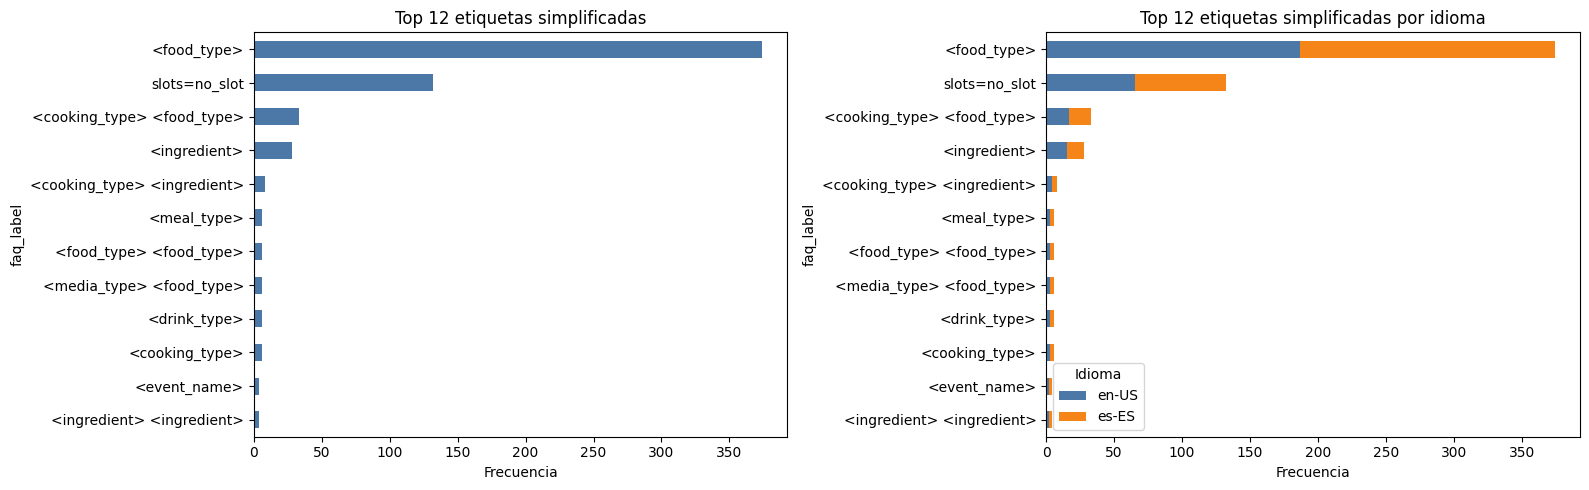

Etiqueta simplificada más frecuente: <food_type> (374 ocurrencias)



,frecuencia
faq_label,
<food_type>,374
slots=no_slot,132
<cooking_type> <food_type>,33
<ingredient>,28
<cooking_type> <ingredient>,8
<meal_type>,6
<cooking_type>,6
<drink_type>,6
<media_type> <food_type>,6


In [55]:
# ── Distribución de etiquetas simplificadas ──────────────
TOP_N = 12

if len(df_cooking) > 0:
    faq_freq = df_cooking['faq_label'].value_counts().sort_values(ascending=False)
    faq_locale = pd.crosstab(df_cooking['faq_label'], df_cooking['locale'])
    top_faq = faq_freq.head(TOP_N).index.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    faq_freq.head(TOP_N).sort_values().plot(kind='barh', ax=axes[0], color='#4C78A8')
    axes[0].set_title(f'Top {TOP_N} etiquetas simplificadas')
    axes[0].set_xlabel('Frecuencia')
    axes[0].set_ylabel('faq_label')

    (
        faq_locale.loc[top_faq]
        .assign(total=lambda x: x.sum(axis=1))
        .sort_values('total')
        .drop(columns='total')
        .plot(kind='barh', stacked=True, ax=axes[1], color=['#4C78A8', '#F58518'])
    )
    axes[1].set_title(f'Top {TOP_N} etiquetas simplificadas por idioma')
    axes[1].set_xlabel('Frecuencia')
    axes[1].set_ylabel('faq_label')
    axes[1].legend(title='Idioma')

    plt.tight_layout()
    plt.savefig('fig_distribucion_clases.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Etiqueta simplificada más frecuente: {faq_freq.idxmax()} ({faq_freq.iloc[0]:,} ocurrencias)")
    print()
    display(faq_freq.head(15).rename('frecuencia').to_frame())
else:
    print('[Sin datos cooking]')


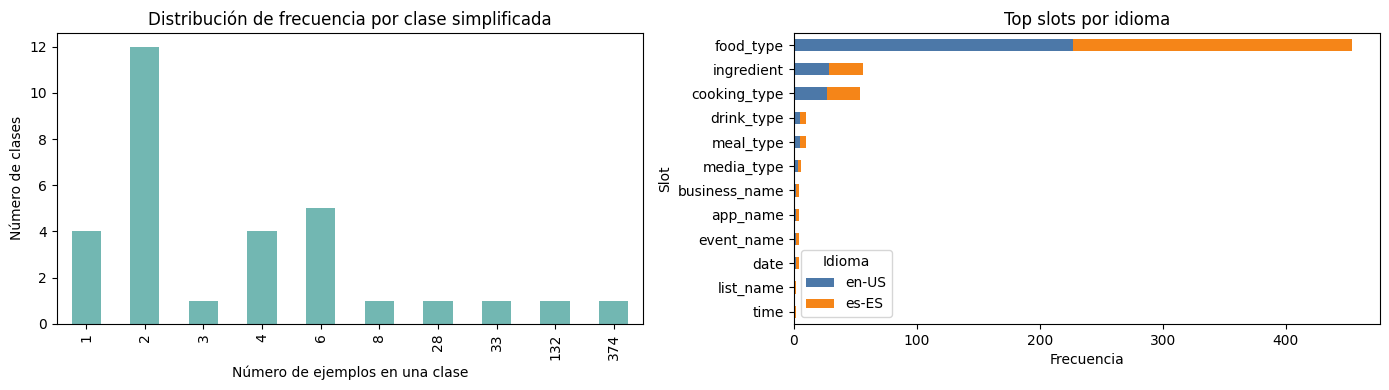

Slot más frecuente: food_type (454 ocurrencias)

Clases simplificadas con un solo ejemplo: 4
Media de ejemplos por clase simplificada: 21.03



,frecuencia
slot,
food_type,454
ingredient,56
cooking_type,54
meal_type,10
drink_type,10
media_type,6
date,4
event_name,4
app_name,4


In [56]:
# ── Slots y frecuencia de clases simplificadas ───────────
if len(df_cooking) > 0:
    faq_freq = df_cooking['faq_label'].value_counts().sort_values(ascending=False)
    freq_dist = faq_freq.value_counts().sort_index()
    slot_freq = df_slots['slot'].value_counts().sort_values(ascending=False)
    slot_locale = pd.crosstab(df_slots['slot'], df_slots['locale'])
    top_slots = slot_freq.head(12).index.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    freq_dist.plot(kind='bar', ax=axes[0], color='#72B7B2')
    axes[0].set_title('Distribución de frecuencia por clase simplificada')
    axes[0].set_xlabel('Número de ejemplos en una clase')
    axes[0].set_ylabel('Número de clases')

    (
        slot_locale.loc[top_slots]
        .assign(total=lambda x: x.sum(axis=1))
        .sort_values('total')
        .drop(columns='total')
        .plot(kind='barh', stacked=True, ax=axes[1], color=['#4C78A8', '#F58518'])
    )
    axes[1].set_title('Top slots por idioma')
    axes[1].set_xlabel('Frecuencia')
    axes[1].set_ylabel('Slot')
    axes[1].legend(title='Idioma')

    plt.tight_layout()
    plt.savefig('fig_longitud_textos.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Slot más frecuente: {slot_freq.idxmax()} ({slot_freq.iloc[0]:,} ocurrencias)")
    print()
    print(f"Clases simplificadas con un solo ejemplo: {(faq_freq == 1).sum():,}")
    print(f"Media de ejemplos por clase simplificada: {faq_freq.mean():.2f}")
    print()
    display(slot_freq.head(15).rename('frecuencia').to_frame())
else:
    print('[Sin datos cooking]')


In [57]:
# ── Ejemplos de etiquetas simplificadas y slots ──────────
N_TOP = 5
N_EJEMPLOS = 1

if len(df_cooking) > 0:
    slots_por_idioma = df_cooking.groupby('locale')['n_slots'].describe().round(2)
    faq_freq = df_cooking['faq_label'].value_counts().sort_values(ascending=False)
    print('Resumen de slots por utterance y por idioma:')
    print(slots_por_idioma.to_string())
    print()
    print(f"Utterances sin slots: {(df_cooking['n_slots'] == 0).sum():,}")
    print(f"Media de slots por utterance: {df_cooking['n_slots'].mean():.2f}")
    print()
    for faq_label in faq_freq.head(N_TOP).index:
        print(f"\n{'─'*70}")
        print(f"faq_label: {faq_label} | frecuencia={faq_freq[faq_label]}")
        print('─'*70)
        for locale in LOCALES:
            subset = df_cooking[(df_cooking['faq_label'] == faq_label) & (df_cooking['locale'] == locale)]
            if len(subset) == 0:
                continue
            print(f"[{locale}]")
            muestra = subset.sample(min(N_EJEMPLOS, len(subset)), random_state=SEED)
            for _, row in muestra.iterrows():
                print(f"  Texto:  {row['text'][:250]}")
                print(f"  Anot.:  {row['annot_utt'][:250]}")
                print(f"  Annot simplificado: {row['annot_slots_only']}")
                print(f"  Slots:  {row['slots']}")
else:
    print('[Sin datos cooking]')


Resumen de slots por utterance y por idioma:
        count  mean   std  min  25%  50%  75%  max
locale                                            
en-US   326.0  0.94  0.59  0.0  1.0  1.0  1.0  3.0
es-ES   326.0  0.94  0.60  0.0  1.0  1.0  1.0  3.0

Utterances sin slots: 132
Media de slots por utterance: 0.94


──────────────────────────────────────────────────────────────────────
faq_label: <food_type> | frecuencia=374
──────────────────────────────────────────────────────────────────────
[en-US]
  Texto:  list of famous biryani recipes
  Anot.:  list of famous [food_type : biryani] recipes
  Annot simplificado: <food_type>
  Slots:  ['food_type']
[es-ES]
  Texto:  muestra las recetas famosas de huevos duros
  Anot.:  muestra las recetas famosas de [food_type : huevos duros]
  Annot simplificado: <food_type>
  Slots:  ['food_type']

──────────────────────────────────────────────────────────────────────
faq_label: slots=no_slot | frecuencia=132
─────────────────────────────────────────

## 3. Preprocesamiento


In [58]:
import re
import unicodedata

def limpiar_texto(texto: str) -> str:
    if pd.isna(texto):
        return ""
    texto = unicodedata.normalize('NFKC', str(texto)).lower()
    texto = re.sub(r'http\S+|www\S+', ' ', texto)
    texto = re.sub(r'@\w+|#\w+', ' ', texto)
    texto = re.sub(r'[_/\\-]+', ' ', texto)
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

if len(df_cooking) > 0:
    df_cooking['text_clean'] = df_cooking['text'].apply(limpiar_texto)
    df_slots['text_clean'] = df_slots['text'].apply(limpiar_texto)
    print('Preprocesamiento aplicado sobre utterances cooking.')
    for locale in LOCALES:
        muestra = df_cooking[df_cooking['locale'] == locale]
        if len(muestra) == 0:
            continue
        fila = muestra.sample(1, random_state=SEED).iloc[0]
        print(f"\n[{locale}]")
        print('Original:', fila['text'][:200])
        print('Limpio:  ', fila['text_clean'][:200])
else:
    df_cooking['text_clean'] = df_cooking['text']
    df_slots['text_clean'] = df_slots['text']
    print('[Sin datos — preprocesamiento definido pero no aplicado]')


Preprocesamiento aplicado sobre utterances cooking.

[en-US]
Original: how do i make meatloaf
Limpio:   how do i make meatloaf

[es-ES]
Original: cómo hago un pastel de carne
Limpio:   cómo hago un pastel de carne


## 4. Entrenamiento de modelo(s)


In [59]:
TEXT_COL = 'text_clean'
LABEL_COL = 'label'
TEST_SIZE = 0.2

if len(df_cooking) > 0:
    df_model = df_cooking.copy()
    df_model['label'] = df_model['faq_label'].astype(str)
    class_counts = df_model['label'].value_counts()
    stratify = df_model['label'] if class_counts.min() >= 2 and df_model['label'].nunique() > 1 else None

    df_train, df_test = train_test_split(
        df_model,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=stratify,
    )

    X_train = df_train[TEXT_COL].tolist()
    y_train = df_train[LABEL_COL].tolist()
    X_test = df_test[TEXT_COL].tolist()
    y_test = df_test[LABEL_COL].tolist()

    print(f'Total utterances cooking: {len(df_model):,}')
    print(f'Train: {len(df_train):,} | Test: {len(df_test):,}')
    print(f'Clases simplificadas distintas: {df_model[LABEL_COL].nunique()}')
else:
    df_train = pd.DataFrame()
    df_test = pd.DataFrame()
    X_train, y_train, X_test, y_test = [], [], [], []
    print('[Sin datos — definir df_cooking primero]')


Total utterances cooking: 652
Train: 521 | Test: 131
Clases simplificadas distintas: 31
